In [22]:
# imports

import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

#sklearn for regression 
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import AdaBoostRegressor,RandomForestRegressor
from sklearn.svm import SVR
from catboost import CatBoostRegressor
from xgboost import XGBRegressor

#metrices
from sklearn.metrics import r2_score,mean_squared_error
from sklearn.model_selection import RandomizedSearchCV

#preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

import warnings

In [23]:
#import dataset
df = pd.read_csv('data/Stud.csv')

In [24]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [25]:
#preparing x and y 
x = df.drop('writing_score',axis=1)
y = df['writing_score']

### Transformation Pipeline

In [26]:
#create a seprate numerical features and categorical features 
num_features = x.select_dtypes(exclude="object").columns
cat_features = x.select_dtypes(include="object").columns

numeric_transform = StandardScaler()
category_transform = OneHotEncoder(drop="first")

preprocessing = ColumnTransformer(
    [
        ("OneHotEncoder",category_transform,cat_features),
        ("StandardScaler",numeric_transform,num_features)
    ]
)

In [27]:
x = preprocessing.fit_transform(x)

### train test split

In [28]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.25,random_state=42)

### EVALUATION PIPELINE

In [29]:
def eval(true,predicted):
    mae = mean_squared_error(true,predicted)
    rmse = np.sqrt(mae)
    r2 = r2_score(true,predicted)
    return mae,rmse,r2

### MODEL TRAINING

In [30]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest Regressor": RandomForestRegressor(),
    "XGBRegressor": XGBRegressor(), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor()
}
model_list = []
r2_list =[]


for i in range(len(list(models))):
    model = list(models.values())[i]
    model.fit(x_train, y_train) # Train model

    # Make predictions
    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)
    
    # Evaluate Train and Test dataset
    model_train_mae , model_train_rmse, model_train_r2 = eval(y_train, y_train_pred)

    model_test_mae , model_test_rmse, model_test_r2 = eval(y_test, y_test_pred)

    
    print(list(models.keys())[i])
    model_list.append(list(models.keys())[i])
    
    print('Model performance for Training set')
    print("- Root Mean Squared Error: {:.4f}".format(model_train_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_train_mae))
    print("- R2 Score: {:.4f}".format(model_train_r2))

    print('----------------------------------')
    
    print('Model performance for Test set')
    print("- Root Mean Squared Error: {:.4f}".format(model_test_rmse))
    print("- Mean Absolute Error: {:.4f}".format(model_test_mae))
    print("- R2 Score: {:.4f}".format(model_test_r2))
    r2_list.append(model_test_r2)
    
    print('='*35)
    print('\n')

Linear Regression
Model performance for Training set
- Root Mean Squared Error: 3.3576
- Mean Absolute Error: 11.2732
- R2 Score: 0.9488
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 3.8159
- Mean Absolute Error: 14.5610
- R2 Score: 0.9435


Lasso
Model performance for Training set
- Root Mean Squared Error: 4.5143
- Mean Absolute Error: 20.3791
- R2 Score: 0.9075
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 4.9200
- Mean Absolute Error: 24.2063
- R2 Score: 0.9060


Ridge
Model performance for Training set
- Root Mean Squared Error: 3.3577
- Mean Absolute Error: 11.2738
- R2 Score: 0.9488
----------------------------------
Model performance for Test set
- Root Mean Squared Error: 3.8154
- Mean Absolute Error: 14.5574
- R2 Score: 0.9435


K-Neighbors Regressor
Model performance for Training set
- Root Mean Squared Error: 3.8586
- Mean Absolute Error: 14.8891
- R2 Score: 0.9324
----------------

In [31]:
### result
pd.DataFrame(list(zip(model_list, r2_list)), columns=['Model Name', 'R2_Score']).sort_values(by=["R2_Score"],ascending=False)

,Model Name,R2_Score
2,Ridge,0.943479
0,Linear Regression,0.943465
7,CatBoosting Regressor,0.923176
6,XGBRegressor,0.919439
5,Random Forest Regressor,0.918587
8,AdaBoost Regressor,0.914105
1,Lasso,0.906016
3,K-Neighbors Regressor,0.887749
4,Decision Tree,0.877647


### continue with linear regression

In [33]:
reg = LinearRegression()
reg.fit(x_train,y_train)
y_predict = reg.predict(x_test)

score = r2_score(y_predict,y_test)
print(f'accuracy of the model is {score}')

accuracy of the model is 0.9393353191546308


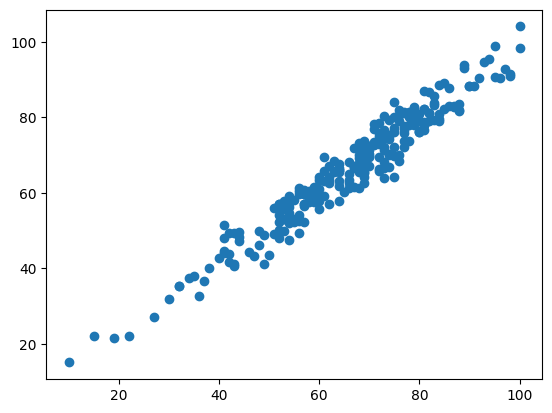

In [42]:
### plotting actual and predicted
plt.scatter(y_test,y_predict);

<Axes: xlabel='writing_score'>

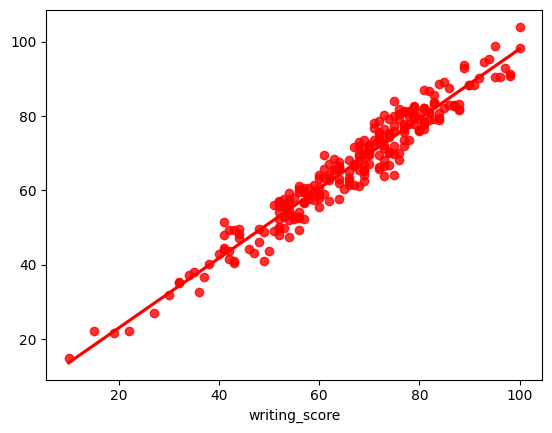

In [43]:
sns.regplot(x=y_test,y=y_predict,ci=None,color='red')

In [47]:
#diffrence between predicted values and actual values

diff = pd.DataFrame({'Actual values':y_test,'predicted values':y_predict,'Diffrence':y_predict-y_test})
diff

,Actual values,predicted values,Diffrence
521,84,88.612501,4.612501
737,73,66.689023,-6.310977
740,72,73.611513,1.611513
660,73,71.397238,-1.602762
411,78,79.953414,1.953414
...,...,...,...
109,72,65.841831,-6.158169
430,59,61.543759,2.543759
77,81,78.118726,-2.881274
84,34,37.328609,3.328609


In [71]:
high_values = []
for difs in diff['Diffrence']:
    if difs >= 10:
        high_values.append(difs)
    
print(len(high_values),high_values)

1 [10.447193024210122]
